Heart Disease dataset Shape:(800, 12)

Datatypes in dataset:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Count of Missing Values in Dataset:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows in dataset:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0 

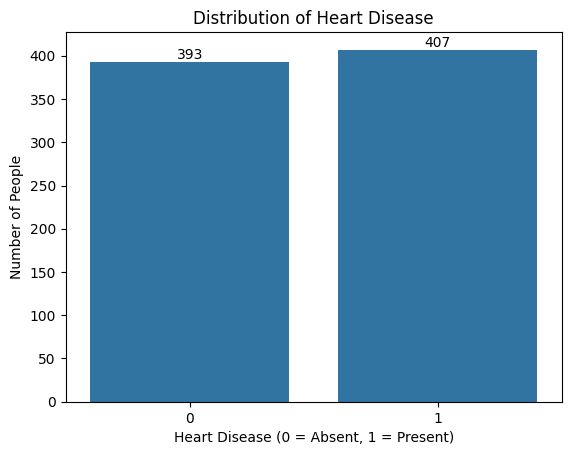

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Q1. Supervised Learning 
# Task 1. Data Loading and Inspection
heart_disease = pd.read_csv('data/q1_heart_disease.csv')
print(f'Heart Disease dataset Shape:{heart_disease.shape}')
print(f'\nDatatypes in dataset:\n{heart_disease.dtypes}')
print(f'\nCount of Missing Values in Dataset:\n{heart_disease.isnull().sum()}')
print(f'\nFirst 5 rows in dataset:\n{heart_disease.head(5)}')

# Task 2. Exploratory Data Analysis

#Visualization - Target Class Distribution Plot - Distribution of Patients With and Without Heart Disease
print("\nTarget Class Distribution Plot - Distribution of Patients With and Without Heart Disease:\n")
ax = sns.countplot(x='heart_disease', data=heart_disease)
# Add labels on top of bars
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Heart Disease (0 = Absent, 1 = Present)")
plt.ylabel("Number of People")
plt.title("Distribution of Heart Disease")
plt.show()

The distribution shows a slightly higher number of individuals with heart disease(407) compared to those without(373).This difference is minimal indicating a well-balanced dataset. This balance helps in preventing bias during model training and improves the reliability of predictions.


 Chart showing Feature Correlation for Heart Disease Analysis:


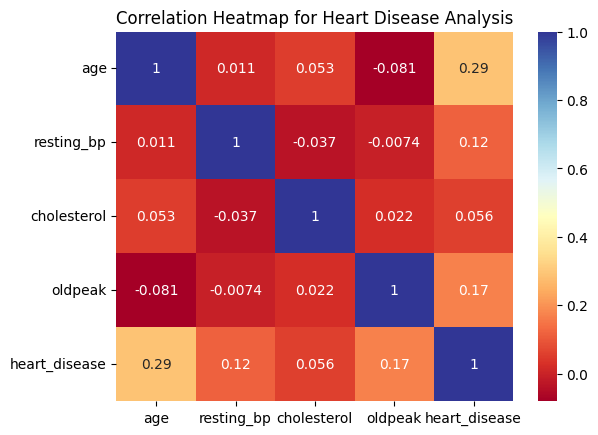

In [18]:
#Visualiztion - Feature Correlation Heatmap for Heart Disease Analysis

print('\n Chart showing Feature Correlation for Heart Disease Analysis:')

corr_df = heart_disease[['age', 'resting_bp','cholesterol','oldpeak','heart_disease']]
corr_matrix = corr_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu')
plt.title('Correlation Heatmap for Heart Disease Analysis')
plt.show()

1) The correlation heatmap indicates that age and oldpeak have relatively higher positive correlations with the target variable (heart disease) compared to the other features. This indicates that they are more important predictors in the dataset. 
2) The cholesterol feature shows very weak correlation with both the target and other variables, indicating limited individual influence.
3) Overall, the dataset does not exhibit strong correlations among the features

Chart showing distribution of cholestrol levels among people:



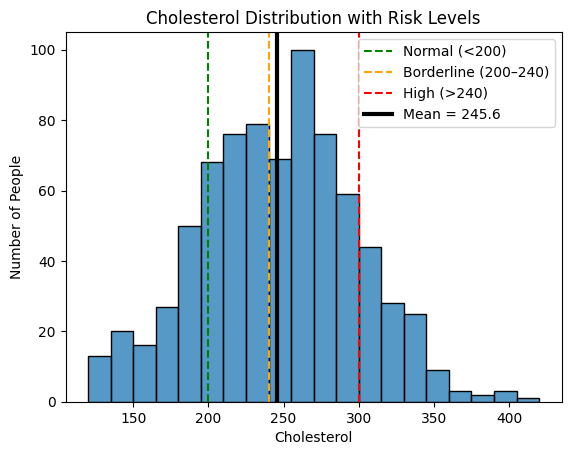

In [19]:
#Visualization - Histogram for showing distribution of cholestrol levels among people
print("Chart showing distribution of cholestrol levels among people:\n")
sns.histplot(heart_disease['cholesterol'], bins=20)

# Vertical lines for showing cholestrol thresholds
plt.axvline(200, color='green', linestyle='--', label='Normal (<200)')
plt.axvline(240, color='orange', linestyle='--', label='Borderline (200–240)')
plt.axvline(300, color='red', linestyle='--', label='High (>240)') 

# Midpoint (mean)
mean_val = heart_disease['cholesterol'].mean()
plt.axvline(
    mean_val,
    linestyle='-',
    linewidth=3,
    color='black',
    label=f'Mean = {mean_val:.1f}'
)

plt.xlabel("Cholesterol")
plt.ylabel("Number of People")
plt.title("Cholesterol Distribution with Risk Levels")

plt.legend()
plt.show()

1) The histogram shows a roughly normal distribution with most values concentrated in the middle range. However it slightly right skewed also. 
2) The above chart shows that majority of borderline and high cholestrol level people fall above the mean value i.e. there are significant number of people who are at risk for heart disease
3) Majority of people fall in the range of borderline cholestrol levels 
4) Very few people in the dataset have normal cholestrol levels that also implies that these values are less common in the dataset.
5) There are some people who have very high levels of cholestrol indicating high risk patients in the dataset

In [20]:
# Task 3. Data Preprocessing

# Handling Missing Values
heart_disease['resting_bp'] = heart_disease['resting_bp'].fillna(heart_disease['resting_bp'].median())
heart_disease['cholesterol'] = heart_disease['cholesterol'].fillna(heart_disease['cholesterol'].median())

The dataset contained missing values in the 'resting_bp' and 'cholesterol' columns. These were handled using median imputation, as both features exhibit a wide range of values and potential outliers. So median is a more reliable measure than the mean. Row drop was not consdered to prevent loss of valuable data.

In [21]:
# Application of one-hot encoding to all categorical variables
from sklearn.preprocessing import OneHotEncoder

# Columns to encode
categorical_cols = ['chest_pain_type','resting_ecg','st_slope']
numerical_cols = heart_disease.select_dtypes(include = 'number').columns

print(f'\nCategorical Columns in the dataset are: \n{categorical_cols}')
print(f'\nNumerical Columns in the dataset are: \n{numerical_cols}')

# --Creating encoder
encoder = OneHotEncoder(drop='first', sparse_output = False)

# --Fitting & transforming all columns
encoded = encoder.fit_transform(heart_disease[categorical_cols])

# --Getting column names
new_col_names = encoder.get_feature_names_out(categorical_cols)
print(f'\nNew Columns for the dataset are: \n{new_col_names}')

# --Converting to DataFrame
encoded_df = pd.DataFrame(encoded, columns=new_col_names)

# --Aligning index
encoded_df.index = heart_disease.index

# --Dropping original columns and merge
print(f'\n Original Dataset: \n{heart_disease.head()}')
heart_disease = heart_disease.drop(categorical_cols, axis=1)
print(f'\n Dataset after droping categorical columns: \n{heart_disease.head()}')
heart_disease = pd.concat([heart_disease, encoded_df], axis=1)
print(f'\n Dataset after adding new columns: \n{heart_disease.head()}')


Categorical Columns in the dataset are: 
['chest_pain_type', 'resting_ecg', 'st_slope']

Numerical Columns in the dataset are: 
Index(['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr',
       'exercise_angina', 'oldpeak', 'heart_disease'],
      dtype='str')

New Columns for the dataset are: 
['chest_pain_type_atypical_angina' 'chest_pain_type_non_anginal'
 'chest_pain_type_typical_angina' 'resting_ecg_normal'
 'resting_ecg_st_t_wave_abnormality' 'st_slope_flat' 'st_slope_up']

 Original Dataset: 
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0           0   
4   37    1      non_anginal       149.0        271.0           0   

                    resting_ecg  max_hr  exercise_angina  oldpea

In [22]:
# Scaling numerical features using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = numerical_cols.drop('heart_disease')
heart_disease[numerical_cols] = scaler.fit_transform(heart_disease[numerical_cols])
heart_disease.describe()

,age,sex,resting_bp,cholesterol,fasting_bs,max_hr,exercise_angina,oldpeak,heart_disease,chest_pain_type_atypical_angina,chest_pain_type_non_anginal,chest_pain_type_typical_angina,resting_ecg_normal,resting_ecg_st_t_wave_abnormality,st_slope_flat,st_slope_up
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,2.642331e-16,-3.108624e-17,-4.618528e-16,-1.787459e-16,-9.769963e-17,-4.551914e-16,5.773160e-17,6.661338e-18,0.508750,0.172500,0.265000,0.080000,0.506250,0.365000,0.337500,0.485000
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,0.500236,0.378051,0.441609,0.271463,0.500274,0.481731,0.473153,0.500088
min,-1.726385e+00,-1.408927e+00,-2.516828e+00,-2.459514e+00,-5.503922e-01,-3.267971e+00,-6.468692e-01,-1.031714e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.706319e-01,-1.408927e+00,-6.593333e-01,-6.590700e-01,-5.503922e-01,-6.766480e-01,-6.468692e-01,-6.972851e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.291733e-02,7.097601e-01,-4.016832e-02,2.588138e-02,-5.503922e-01,-6.478307e-03,-6.468692e-01,-3.628558e-01,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,8.408750e-01,7.097601e-01,7.028296e-01,6.325526e-01,-5.503922e-01,7.083693e-01,1.545908e+00,4.174792e-01,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
max,1.696628e+00,7.097601e-01,3.303322e+00,3.411498e+00,1.816886e+00,2.361454e+00,1.545908e+00,5.322442e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
# Splitting data

from sklearn.model_selection import train_test_split

X = heart_disease.drop(['heart_disease'], axis=1)
y = heart_disease['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Heart Disease counts & %
# Heart Disease Present is 1 and Heart Disease Absent is 0
train_total = len(y_train)
test_total  = len(y_test)

train_heart_disease_present = (y_train == 1).sum()
test_heart_disease_present  = (y_test == 1).sum()

train_heart_disease_pct = 100.0 * train_heart_disease_present / train_total
test_heart_disease_pct  = 100.0 * test_heart_disease_present / test_total

print("TRAIN:")
print(f"  Total = {train_total:,}")
print(f"  Heart Disease Present = {train_heart_disease_present:,}")
print(f"  Heart Disease% = {train_heart_disease_pct:.2f}%")

print("\nTEST:")
print(f"  Total = {test_total:,}")
print(f"  Heart Disease Present = {test_heart_disease_present:,}")
print(f"  Heart Disease% = {test_heart_disease_pct:.2f}%")

TRAIN:
  Total = 640
  Heart Disease Present = 326
  Heart Disease% = 50.94%

TEST:
  Total = 160
  Heart Disease Present = 81
  Heart Disease% = 50.62%



---------Decision Tree Classifier---------


Decision Tree Confusion Matrix:



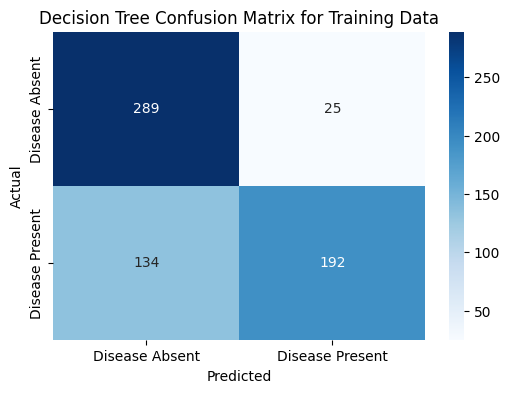

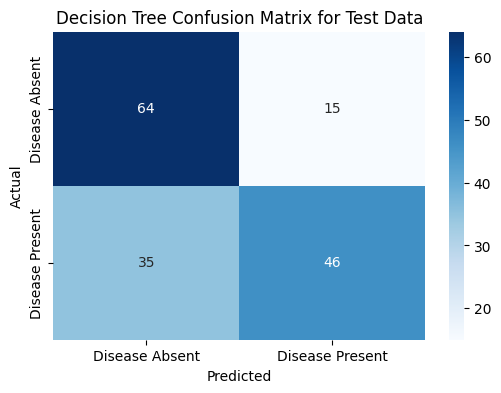


Decision Tree Metrics:

Decision Tree Test Accuracy: 0.6875
Decision Tree Test Recall: 0.5679012345679012
Decision Tree Test Precision: 0.7540983606557377
Test F1 Score: 0.647887323943662


In [24]:
# Task 4. Model Training & 
# Task 5. Model Evaluation

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, roc_curve
from sklearn.metrics import recall_score,precision_score,f1_score

print('\n---------Decision Tree Classifier---------\n')

dt = DecisionTreeClassifier(max_depth=3,random_state=42)
dt.fit(X_train, y_train)

# Predictions
# --run the model on training data for prediction
dt_train_pred = dt.predict(X_train)

# --run the model on test data for prediction
dt_pred = dt.predict(X_test)

# -------- CONFUSION MATRIX --------
print('\nDecision Tree Confusion Matrix:\n')

# -------- TRAIN CONFUSION MATRIX --------
cm_dt = confusion_matrix(y_train, dt_train_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Disease Absent', 'Disease Present'], yticklabels=['Disease Absent', 'Disease Present'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix for Training Data')
plt.show()

# -------- TEST CONFUSION MATRIX --------
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Disease Absent', 'Disease Present'], yticklabels=['Disease Absent', 'Disease Present'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix for Test Data')
plt.show()

# --------- DECISION TREE METRICS --------
print('\nDecision Tree Metrics:')

# -------- TEST METRICS --------
print("\nDecision Tree Test Accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree Test Recall:", recall_score(y_test, dt_pred))
print("Decision Tree Test Precision:", precision_score(y_test, dt_pred))
print("Test F1 Score:", f1_score(y_test, dt_pred))









---------Random Forest Classifier---------




Random Forest Confusion Matrix:



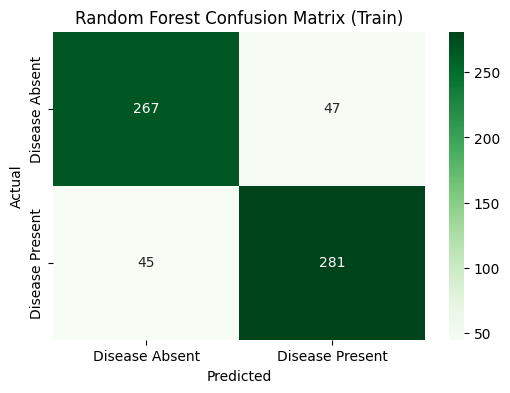

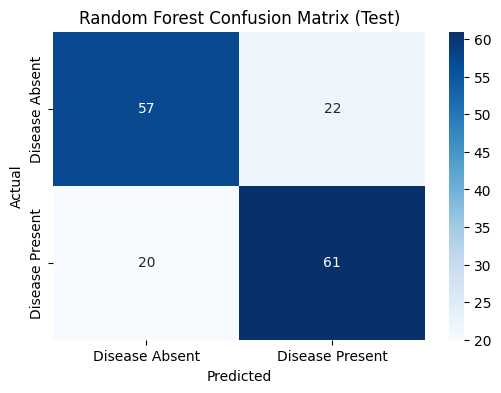


Random Forest Metrics:

Random Forest Test Accuracy: 0.7375
Random Forest Test Precision: 0.7349397590361446
Random Forest Test Recall: 0.7530864197530864
Random Forest Test F1 Score: 0.7439024390243902


In [25]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

print('\n---------Random Forest Classifier---------\n')

rf = RandomForestClassifier(n_estimators=100, max_depth=3,random_state=42)
rf.fit(X_train, y_train)

# Predictions
rf_train_pred = rf.predict(X_train)  # Train data
rf_pred = rf.predict(X_test)         # Test data

# -------- CONFUSION MATRIX --------
print('\nRandom Forest Confusion Matrix:\n')

# -------- TRAIN CONFUSION MATRIX --------
cm_rf_train = confusion_matrix(y_train, rf_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Disease Absent', 'Disease Present'],
            yticklabels=['Disease Absent', 'Disease Present'])
plt.title('Random Forest Confusion Matrix (Train)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -------- TEST CONFUSION MATRIX --------
cm_rf_test = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Disease Absent', 'Disease Present'],
            yticklabels=['Disease Absent', 'Disease Present'])
plt.title('Random Forest Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# --------- DECISION TREE METRICS --------
print('\nRandom Forest Metrics:')


# -------- TEST METRICS --------
print("\nRandom Forest Test Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Test Precision:", precision_score(y_test, rf_pred))
print("Random Forest Test Recall:", recall_score(y_test, rf_pred))
print("Random Forest Test F1 Score:", f1_score(y_test, rf_pred))





---------Gradient Boosting Classifier---------


Gradient Boosting Confusion Matrix:



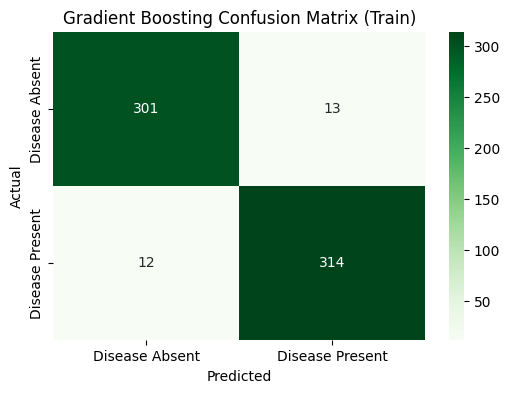

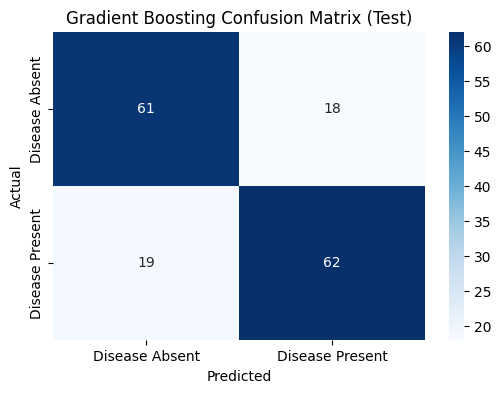


Gradient Boosting Metrics:

Gradient Boosting Test Accuracy: 0.76875
Gradient Boosting Test Precision: 0.775
Gradient Boosting Test Recall: 0.7654320987654321
Gradient Boosting Test F1 Score: 0.7701863354037267


In [26]:
# Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier
print('\n---------Gradient Boosting Classifier---------\n')

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)

# Predictions
gb_train_pred = gb.predict(X_train)  # Train data
gb_pred = gb.predict(X_test)         # Test data

# -------- CONFUSION MATRIX --------
print('\nGradient Boosting Confusion Matrix:\n')

# -------- TRAIN CONFUSION MATRIX --------
cm_gb_train = confusion_matrix(y_train, gb_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Disease Absent', 'Disease Present'],
            yticklabels=['Disease Absent', 'Disease Present'])
plt.title('Gradient Boosting Confusion Matrix (Train)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -------- TEST CONFUSION MATRIX --------
cm_gb_test = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Disease Absent', 'Disease Present'],
            yticklabels=['Disease Absent', 'Disease Present'])
plt.title('Gradient Boosting Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# -------- METRICS --------
print('\nGradient Boosting Metrics:')


# -------- TEST METRICS --------
print("\nGradient Boosting Test Accuracy:", accuracy_score(y_test, gb_pred))
print("Gradient Boosting Test Precision:", precision_score(y_test, gb_pred))
print("Gradient Boosting Test Recall:", recall_score(y_test, gb_pred))
print("Gradient Boosting Test F1 Score:", f1_score(y_test, gb_pred))

Gradient Boosting performs the best among the three models as it achieves the highest precision, recall, and F1 score. It's superior F1 score indicates a better balance between precision and recall. Since this is a medical prediction task, recall and F1 are particularly important, as they help ensure that most disease cases are correctly identified.Additionalyy, the high precision value indicates fewer false positives which is also crucial for reliable predictions.

In [29]:
# Task 6. Hyperparameter Tuning (GridSearchCV)

from sklearn.model_selection import GridSearchCV

# -------- BASELINE MODEL --------
gd_base = gb
gb_base_pred = gb_pred

# -------- GRID SEARCH (TUNE learning_rate) --------

# Defining the parameter grid
param_grid = {
    'learning_rate' : [0.01,0.05,0.09,0.1,0.2]
    }

# Initializing the Grid Search
grid_search = GridSearchCV(
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs = -1
)

print("Starting Grid Search... this may take a moment.")
grid_search.fit(X_train, y_train)

# Best Model
best_gb = grid_search.best_estimator_

# Best Results
print(f"\nBest Parameters: {grid_search.best_params_}")

# -------- TUNED MODEL --------
gb_tuned_pred = best_gb.predict(X_test)


# -------- TUNED MODEL PERFORMANCE --------

print("\nTuned Model Performance:")
print("Accuracy:", accuracy_score(y_test, gb_tuned_pred))
print("Precision:", precision_score(y_test, gb_tuned_pred))
print("Recall:", recall_score(y_test, gb_tuned_pred))
print("F1 Score:", f1_score(y_test, gb_tuned_pred))


# -------- BASELINE MODEL PERFORMANCE --------

print("\nBaseline Model Performance:")
print("Accuracy:", accuracy_score(y_test, gb_base_pred))
print("Precision:", precision_score(y_test, gb_base_pred))
print("Recall:", recall_score(y_test, gb_base_pred))
print("F1 Score:", f1_score(y_test, gb_base_pred))


Starting Grid Search... this may take a moment.

Best Parameters: {'learning_rate': 0.09}

Tuned Model Performance:
Accuracy: 0.7625
Precision: 0.7654320987654321
Recall: 0.7654320987654321
F1 Score: 0.7654320987654321

Baseline Model Performance:
Accuracy: 0.76875
Precision: 0.775
Recall: 0.7654320987654321
F1 Score: 0.7701863354037267


After tuning the hyperparameter, the model performance slightly decreased. Although GridSearchCV identified a learning rate of 0.09 as the optimal value, the baseline Gradient Boosting model with a learning rate of 0.1 performs slightly better on the test data. While both models achieve identical recall, the baseline model shows higher accuracy, precision, and F1 score, making it the better overall choice.